# Exploracion por componente y filtros
Comparativa por eje (`X`, `Y`, `Z`) entre señal original, pasabajas, pasaaltas y pasabandas.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

plt.style.use("seaborn-v0_8")
%matplotlib inline


In [7]:
csv_path = "data/S38T20R02.csv"
df = pd.read_csv(csv_path)

print(f"Filas: {len(df)}")
print("Columnas:", df.columns.tolist())
df.head()


Filas: 743
Columnas: ['TimeStamp(s)', 'FrameCounter', 'AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ', 'EulerX', 'EulerY', 'EulerZ']


,TimeStamp(s),FrameCounter,AccX,AccY,AccZ,GyrX,GyrY,GyrZ,EulerX,EulerY,EulerZ
0,0.01,1,-0.015,-0.995,0.193,0.859437,0.171887,-0.802141,102.020901,-0.647443,-25.765921
1,0.02,2,-0.018,-0.993,0.188,0.515662,0.515662,-1.031324,102.026631,-0.635983,-25.760192
2,0.03,3,-0.020,-0.993,0.188,0.458366,0.630254,-1.031324,102.032361,-0.630254,-25.748733
3,0.04,4,-0.022,-0.992,0.188,0.458366,0.744845,-0.974029,102.038090,-0.618795,-25.743003
4,0.05,5,-0.023,-0.992,0.185,0.515662,0.916733,-0.802141,101.963606,-0.630254,-25.725814


In [47]:
time_col = "TimeStamp(s)"
acc_cols = ["AccX", "AccY", "AccZ"]
gyr_cols = ["GyrX", "GyrY", "GyrZ"]

# Limpieza y tipado
use_cols = [time_col] + acc_cols + gyr_cols
df[use_cols] = df[use_cols].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=use_cols).copy()

# Frecuencia de muestreo estimada a partir del timestamp
dt = df[time_col].diff().dropna().median()
fs = 1.0 / dt
print(f"Frecuencia estimada: {fs:.2f} Hz (dt={dt:.5f} s)")

# Parametros ajustables de filtros
filter_order = 2
highpass_cutoff_hz = 0.3
lowpass_cutoff_hz = 20.0
bandpass_low_hz = 0.5
bandpass_high_hz = 15.0

Frecuencia estimada: 100.00 Hz (dt=0.01000 s)


In [49]:
def butter_filter(signal, fs, cutoff, btype, order=4):
    nyq = 0.5 * fs
    if btype in {"low", "high"}:
        wn = cutoff / nyq
    elif btype == "band":
        wn = [cutoff[0] / nyq, cutoff[1] / nyq]
    else:
        raise ValueError("btype debe ser 'low', 'high' o 'band'.")

    b, a = butter(order, wn, btype=btype)
    return filtfilt(b, a, signal)


def compare_component(df, time_col, col, fs, order, lp_cut, hp_cut, bp_low, bp_high):
    x = df[time_col].to_numpy()
    y = df[col].to_numpy()

    y_lp = butter_filter(y, fs=fs, cutoff=lp_cut, btype="low", order=order)
    y_hp = butter_filter(y, fs=fs, cutoff=hp_cut, btype="high", order=order)
    y_bp = butter_filter(y, fs=fs, cutoff=(bp_low, bp_high), btype="band", order=order)

    plt.figure(figsize=(14, 4.8))
    plt.plot(x, y, label="Original", linewidth=1.0, alpha=0.7)
    plt.plot(x, y_hp, label=f"Pasaaltas ({hp_cut} Hz)", linewidth=1.5)
    plt.plot(x, y_bp, label=f"Pasabandas ({bp_low}-{bp_high} Hz)", linewidth=1.5)

    plt.title(f"{col} - Comparativa de filtros")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.grid(alpha=0.25)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


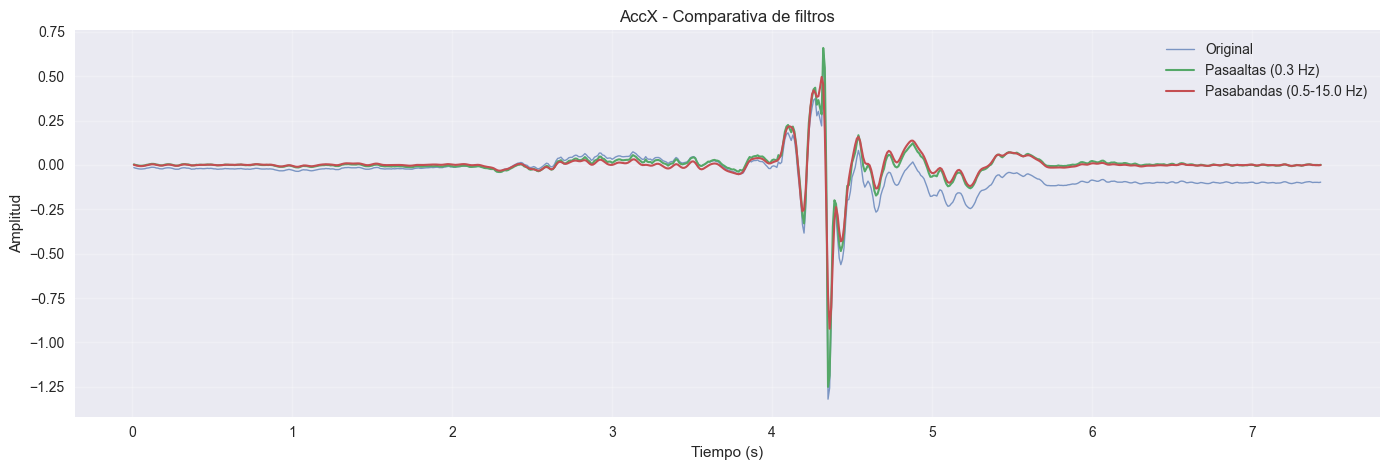

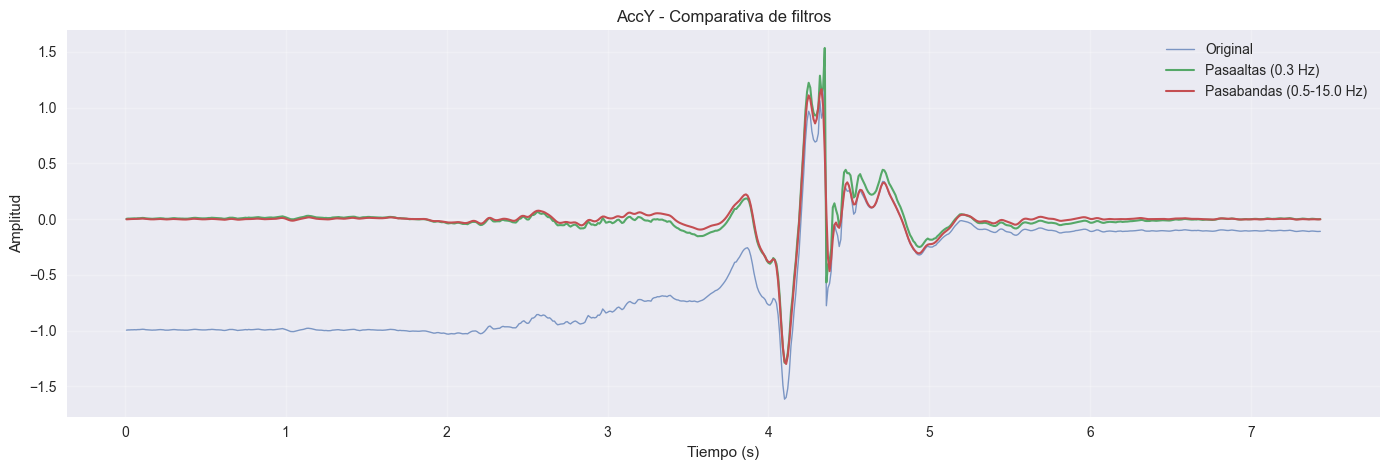

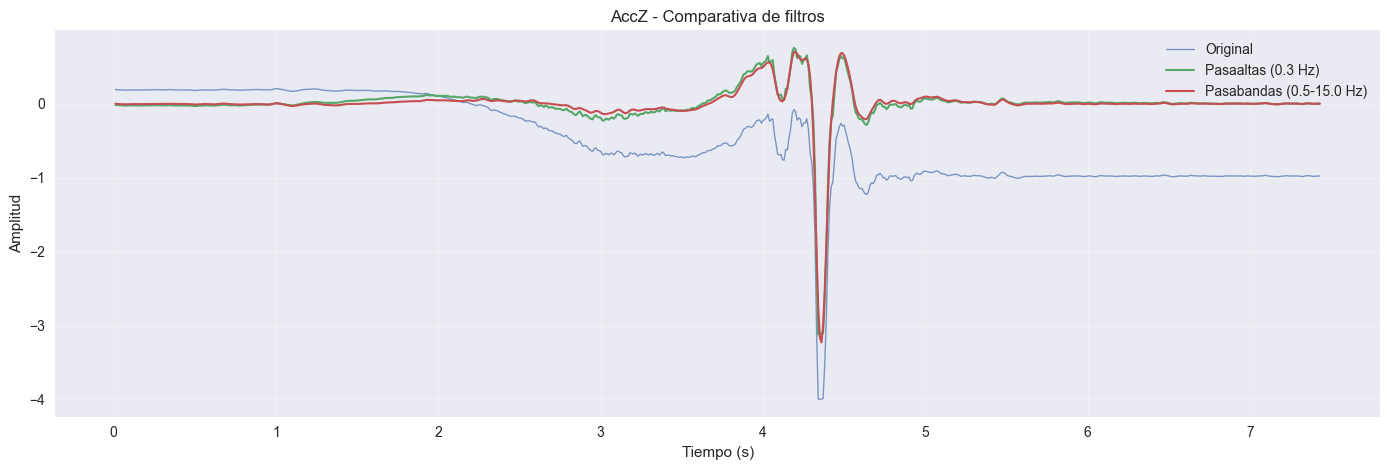

In [50]:
# Acelerometro: una grafica por componente
for component in acc_cols:
    compare_component(
        df=df,
        time_col=time_col,
        col=component,
        fs=fs,
        order=filter_order,
        lp_cut=lowpass_cutoff_hz,
        hp_cut=highpass_cutoff_hz,
        bp_low=bandpass_low_hz,
        bp_high=bandpass_high_hz,
    )


In [ ]:
# Giroscopio: una grafica por componente
for component in gyr_cols:
    compare_component(
        df=df,
        time_col=time_col,
        col=component,
        fs=fs,
        order=filter_order,
        lp_cut=lowpass_cutoff_hz,
        hp_cut=highpass_cutoff_hz,
        bp_low=bandpass_low_hz,
        bp_high=bandpass_high_hz,
    )
